# Notebook 1 — EDA & Power Analysis
**Project:** beats-and-focus  
**Author:** Raquel (Kely) Norel, PhD  
**Data:** 204 tracks — Group A (focus), B (context), C (popular)  

Goals:
1. Understand the data — distributions, missing values, outliers
2. Compare audio features across the three groups
3. Power analysis — how many tracks do we need?

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


In [19]:
df = pd.read_csv('../data/raw/tracks.csv')

print(f'Shape: {df.shape}')
print(f'\nGroups:')
print(df['group'].value_counts())
print(f'\nColumns: {list(df.columns)}')

Shape: (204, 17)

Groups:
group
C_general    70
B_context    68
A_focus      66
Name: count, dtype: int64

Columns: ['track_id', 'track_name', 'artists', 'duration_ms', 'explicit', 'tempo', 'energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'speechiness', 'loudness', 'mode', 'time_signature', 'popularity', 'group']


In [20]:
df.head()

,track_id,track_name,artists,duration_ms,explicit,tempo,energy,valence,danceability,acousticness,instrumentalness,speechiness,loudness,mode,time_signature,popularity,group
0,0c7nSbive39H9is3yVp11B,"ADHD Relief Music, Studying Music for Better C...",Greenred Productions,440840,False,148.038,0.0608,0.3890,0.4440,0.943,0.906,0.0338,-31.999,0,4,37,A_focus
1,2ZYinr81ixwBYE8WzQvNQW,ADHD Focus Music,WorkFlow Music,140063,False,66.620,0.1280,0.0787,0.2150,0.925,0.953,0.0587,-21.959,1,4,34,A_focus
2,2bBpbKcZuPbk5RiCDtnPmi,ADHD Focus Music for Work,WorkFlow Music,139848,False,86.650,0.0181,0.0342,0.1520,0.940,0.987,0.0412,-33.677,1,4,15,A_focus
3,2Fw5S2gaOSZzdN5dFoC2dj,A.D.H.D,Kendrick Lamar,215509,True,157.740,0.7990,0.5820,0.6090,0.330,0.000,0.2400,-6.883,1,4,75,A_focus
4,35F2nANzxZMWOSy9g69m0b,ADHD Focus Music Bilateral,WorkFlow Music,148324,False,67.632,0.0246,0.0340,0.0652,0.930,0.914,0.0396,-33.566,1,3,12,A_focus


In [21]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
track_id            0
track_name          0
artists             0
duration_ms         0
explicit            0
tempo               0
energy              0
valence             0
danceability        0
acousticness        0
instrumentalness    0
speechiness         0
loudness            0
mode                0
time_signature      0
popularity          0
group               0
dtype: int64


In [22]:
audio_features = ['tempo', 'energy', 'valence', 'danceability',
                  'acousticness', 'instrumentalness', 'speechiness', 
                  'loudness', 'popularity']

df.groupby('group')[audio_features].mean().round(3)

,tempo,energy,valence,danceability,acousticness,instrumentalness,speechiness,loudness,popularity
group,,,,,,,,,
A_focus,112.930,0.264,0.296,0.426,0.652,0.588,0.091,-22.933,35.606
B_context,108.721,0.434,0.401,0.531,0.531,0.360,0.098,-15.132,33.029
C_general,120.089,0.624,0.516,0.697,0.201,0.046,0.144,-7.314,34.929


In [23]:
df['group'] = df['group'].replace({'C_popular': 'C_general'})
df.to_csv('../data/raw/tracks.csv', index=False)
print('Done ✓')

Done ✓


In [25]:
group_colors = {'A_focus': '#2196F3', 'B_context': '#4CAF50', 'C_general': '#FF9800'}
group_labels = {'A_focus': 'A — Focus', 'B_context': 'B — Context', 'C_general': 'C — General'}

/var/folders/t4/2qvfdw3d171bl74ql09bhmkh0000gn/T/ipykernel_46537/1435779963.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context', 'C_general']],


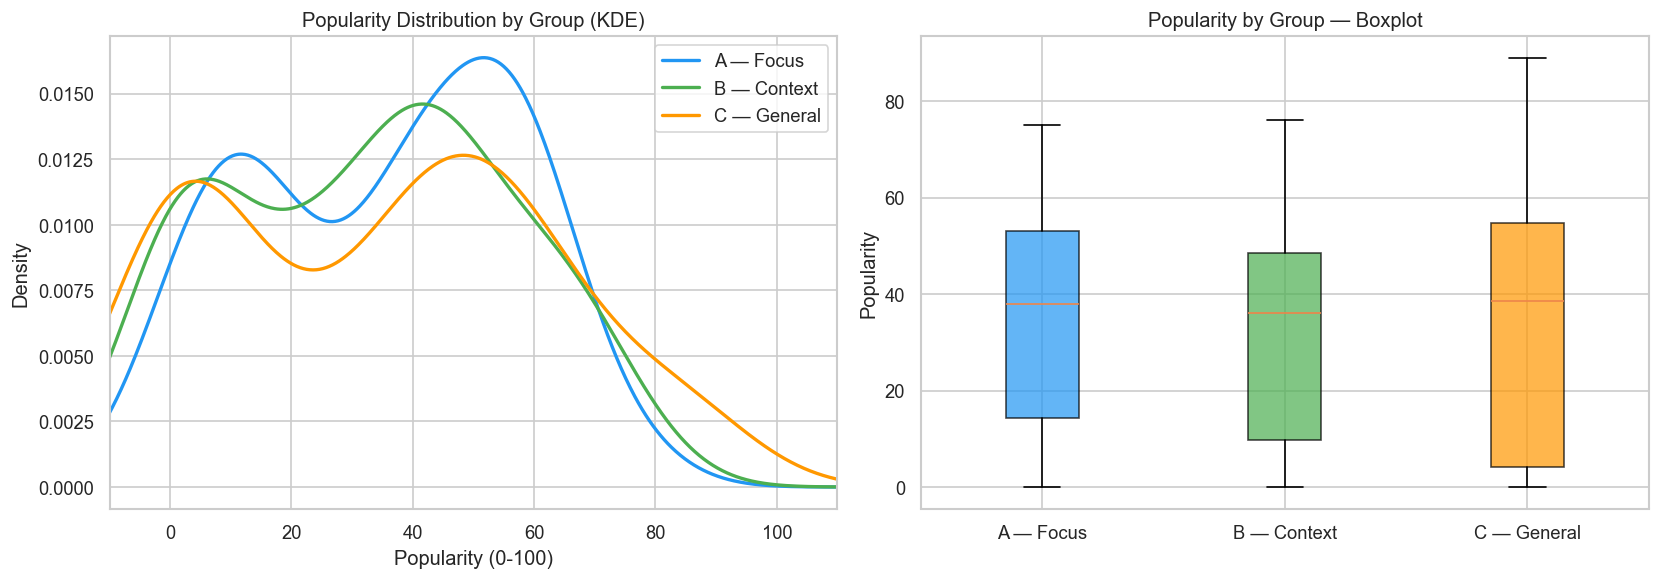

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in group_colors.items():
    subset = df[df['group'] == group]['popularity']
    subset.plot.kde(ax=axes[0], color=color, label=group_labels[group], linewidth=2)

axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Density')
axes[0].set_title('Popularity Distribution by Group (KDE)')
axes[0].legend()
axes[0].set_xlim(-10, 110)

bp_data = [df[df['group'] == g]['popularity'].values for g in ['A_focus', 'B_context', 'C_general']]
bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context', 'C_general']],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity by Group — Boxplot')

plt.tight_layout()
plt.savefig('../figures/01_popularity_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Popularity Distribution

All three groups show remarkably similar popularity distributions:
- Bimodal shape: a peak near 0-10 (niche/unknown tracks) and another near 40-55
- No visible difference between Focus, Context, and General groups
- This is an early signal: **engagement (popularity) does not appear to differ by group**

The key question for the statistical analysis: is any difference between groups 
significant, or just noise?

/var/folders/t4/2qvfdw3d171bl74ql09bhmkh0000gn/T/ipykernel_46537/2863498558.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context', 'C_general']],


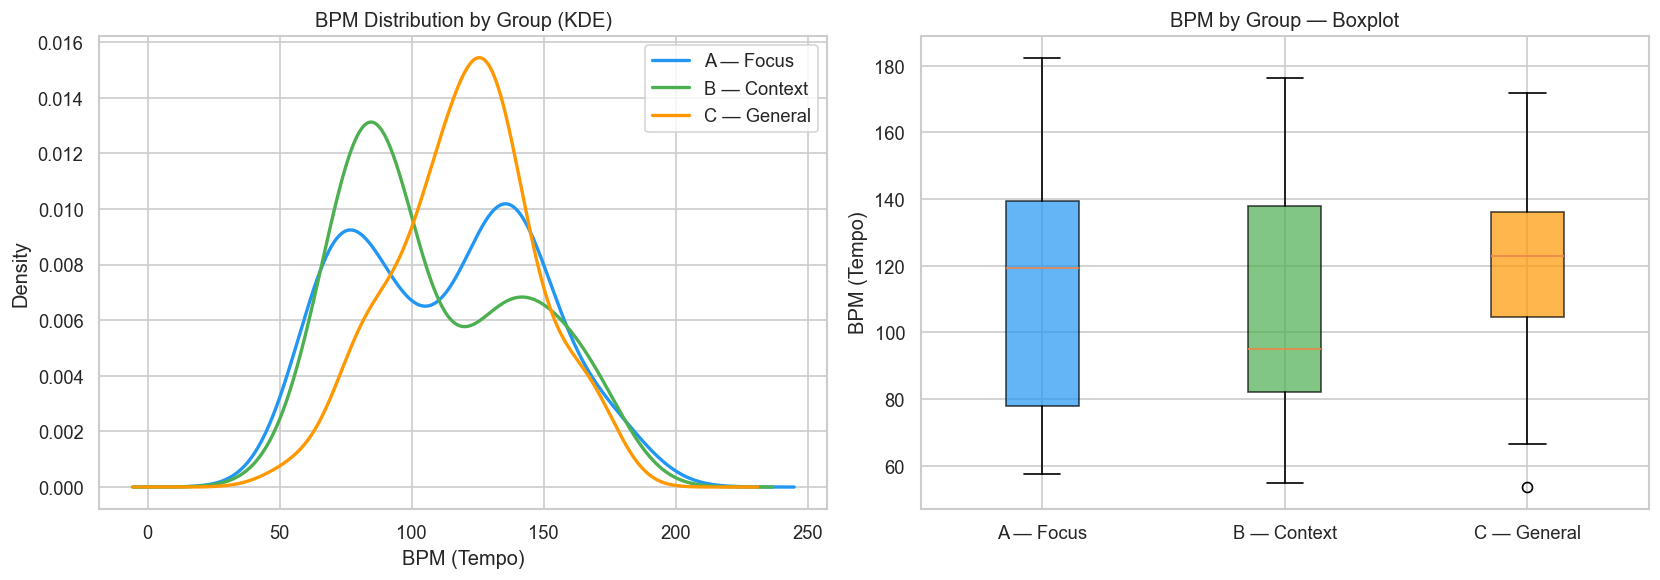

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in group_colors.items():
    subset = df[df['group'] == group]['tempo']
    subset.plot.kde(ax=axes[0], color=color, label=group_labels[group], linewidth=2)

axes[0].set_xlabel('BPM (Tempo)')
axes[0].set_ylabel('Density')
axes[0].set_title('BPM Distribution by Group (KDE)')
axes[0].legend()

bp_data = [df[df['group'] == g]['tempo'].values for g in ['A_focus', 'B_context', 'C_general']]
bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context', 'C_general']],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('BPM (Tempo)')
axes[1].set_title('BPM by Group — Boxplot')

plt.tight_layout()
plt.savefig('../figures/02_bpm_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## BPM (Tempo) Distribution

- C — General (orange) has the tightest, highest peak around 125-130 BPM
- A — Focus (blue) and B — Context (green) are broader and more spread out
- Counterintuitively, Focus tracks do NOT have the highest BPM — General tracks do
- The boxplots confirm similar medians (~120 BPM) across all groups, with high variance in Focus and Context

**This is the first sign that the hypothesis may not hold:**
if high BPM drives focus/engagement, we would expect A_focus to have the highest tempo.
Instead, the "general" mainstream music is faster.

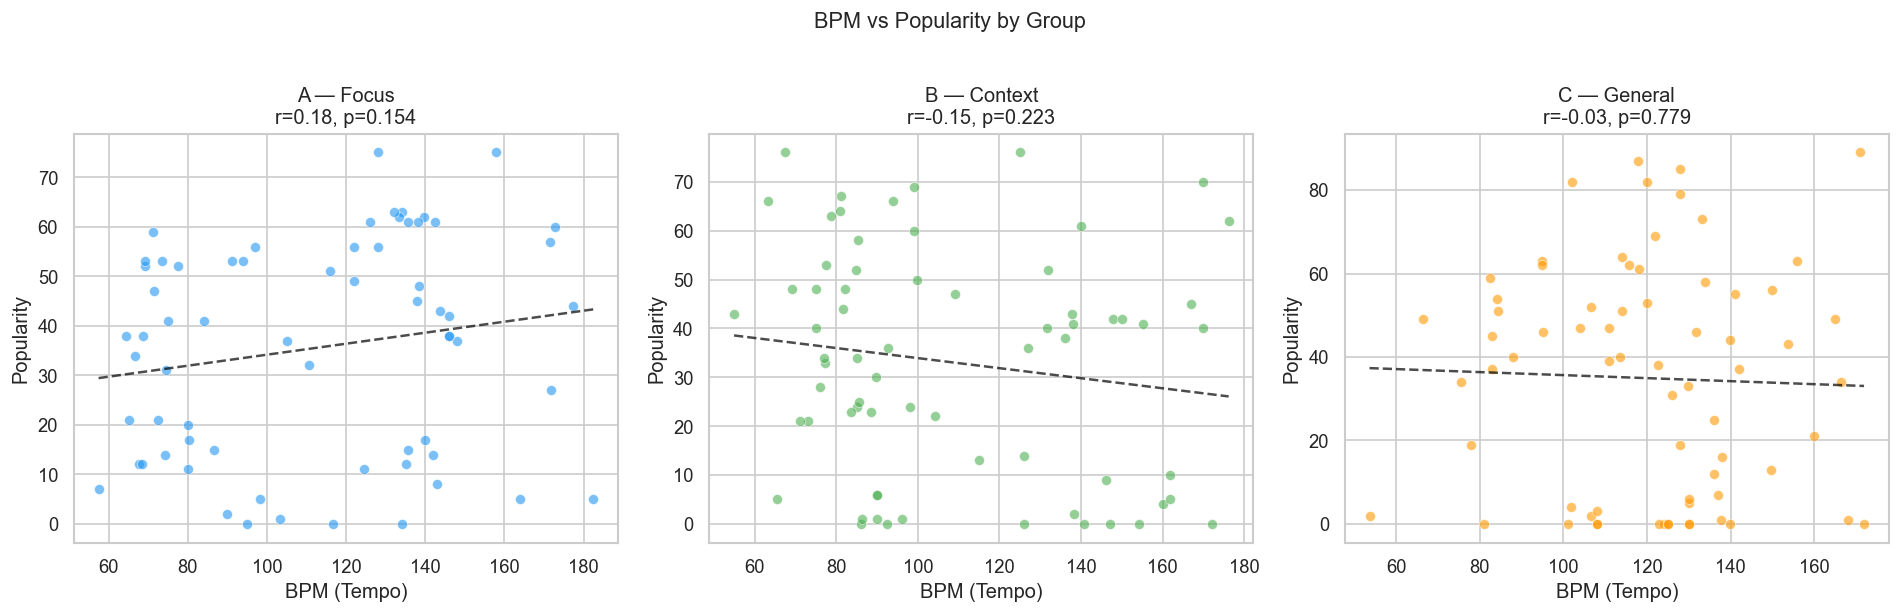

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (group, color) in zip(axes, group_colors.items()):
    subset = df[df['group'] == group]
    ax.scatter(subset['tempo'], subset['popularity'], alpha=0.6, color=color, edgecolors='white', linewidth=0.5)
    
    # Trend line
    z = np.polyfit(subset['tempo'], subset['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['tempo'].min(), subset['tempo'].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Correlation
    r, pval = stats.pearsonr(subset['tempo'], subset['popularity'])
    ax.set_title(f'{group_labels[group]}\nr={r:.2f}, p={pval:.3f}')
    ax.set_xlabel('BPM (Tempo)')
    ax.set_ylabel('Popularity')

plt.suptitle('BPM vs Popularity by Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/03_bpm_vs_popularity.png', dpi=120, bbox_inches='tight')
plt.show()

## BPM vs Popularity — Scatter by Group

- **A — Focus:** r=0.18, p=0.154 — slight positive trend, but NOT significant
- **B — Context:** r=-0.15, p=0.223 — slight negative trend, NOT significant  
- **C — General:** r=-0.03, p=0.779 — essentially zero correlation, NOT significant

**Key finding:** In none of the three groups does BPM significantly predict popularity.
The scatter is wide and the trend lines are nearly flat.

This is strong early evidence against the hypothesis that high BPM drives engagement.
The data is noisy — but the signal is clear: **tempo alone does not predict popularity.**

In [29]:
from statsmodels.stats.power import TTestIndPower

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return abs(group1.mean() - group2.mean()) / pooled_std

pop_A = df[df['group'] == 'A_focus']['popularity']
pop_B = df[df['group'] == 'B_context']['popularity']
pop_C = df[df['group'] == 'C_general']['popularity']

d_AB = cohens_d(pop_A, pop_B)
d_AC = cohens_d(pop_A, pop_C)
d_BC = cohens_d(pop_B, pop_C)

print(f"Cohen's d (A vs B): {d_AB:.3f}")
print(f"Cohen's d (A vs C): {d_AC:.3f}")
print(f"Cohen's d (B vs C): {d_BC:.3f}")
print()
print("Interpretation: small=0.2, medium=0.5, large=0.8")

Cohen's d (A vs B): 0.114
Cohen's d (A vs C): 0.027
Cohen's d (B vs C): 0.075

Interpretation: small=0.2, medium=0.5, large=0.8


In [30]:
power_analysis = TTestIndPower()

print('Sample size needed per group (α=0.05, power=0.80):')
print()
for label, d in [('A vs B', d_AB), ('A vs C', d_AC), ('B vs C', d_BC)]:
    n = power_analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    print(f'  {label}: d={d:.3f} → need {int(np.ceil(n)):,} tracks per group')

print()
print(f'Current sample: ~68 tracks per group')

Sample size needed per group (α=0.05, power=0.80):

  A vs B: d=0.114 → need 1,200 tracks per group
  A vs C: d=0.027 → need 21,204 tracks per group
  B vs C: d=0.075 → need 2,825 tracks per group

Current sample: ~68 tracks per group


## Power Analysis

Effect sizes on popularity between groups are very small:
- A vs B: d=0.114 → need **1,200 tracks per group**
- A vs C: d=0.027 → need 21,204 tracks per group  
- B vs C: d=0.075 → need 2,825 tracks per group

**Decision:** We proceed with A vs B only (Focus vs Context).
Group C (General) is dropped for two reasons:
1. The effect size vs other groups is negligible (d<0.08)
2. The query design did not guarantee a representative "average listener" sample —
   queries like "top hits 2025" returned tracks with similar popularity to focus/context tracks,
   making the group label misleading.

**Target sample:** 1,200 tracks per group (A and B) for 80% power at α=0.05.
Current sample: 66 (A) and 68 (B). Need ~1,130 more per group.

## Reloading Data — Full Sample

After the pilot analysis (n=204), we ran a power analysis that indicated we needed
~1,200 tracks per group to detect the observed effect (d=0.114) with 80% power.

We also simplified the pipeline: Musicae.io handles search, popularity, and audio
features — Spotify is no longer needed. Group C (General) was dropped due to
negligible effect size vs other groups (d<0.08) and ambiguous group definition.

New dataset: **2,021 tracks** — A_focus (949) and B_context (1,072).

In [32]:
df = pd.read_csv('../data/raw/tracks.csv')
print(f'Shape: {df.shape}')
print(df['group'].value_counts())

Shape: (2021, 17)
group
B_context    1072
A_focus       949
Name: count, dtype: int64


In [33]:
print(f'Tracks with tempo = 0: {(df["tempo"] == 0).sum()}')
print(f'Tracks with popularity = 0: {(df["popularity"] == 0).sum()}')

# Remove tempo = 0 (invalid)
df_clean = df[df['tempo'] > 0].copy()
print(f'\nAfter removing tempo=0: {len(df_clean)} tracks')
print(df_clean['group'].value_counts())

Tracks with tempo = 0: 5
Tracks with popularity = 0: 185

After removing tempo=0: 2016 tracks
group
B_context    1069
A_focus       947
Name: count, dtype: int64


## Data Cleaning

- Removed 5 tracks with `tempo = 0` (invalid audio feature return)
- Kept 185 tracks with `popularity = 0` — these are real but unknown tracks, not data errors
- **Final dataset: 2,016 tracks** — A_focus (947) and B_context (1,069)

In [34]:
from statsmodels.stats.power import TTestIndPower

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return abs(group1.mean() - group2.mean()) / pooled_std

pop_A = df_clean[df_clean['group'] == 'A_focus']['popularity']
pop_B = df_clean[df_clean['group'] == 'B_context']['popularity']

d = cohens_d(pop_A, pop_B)
print(f"Cohen's d (A vs B): {d:.3f}")
print(f"Mean popularity A_focus:    {pop_A.mean():.2f}")
print(f"Mean popularity B_context:  {pop_B.mean():.2f}")
print()

power_analysis = TTestIndPower()
n_needed = power_analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
current_power = power_analysis.solve_power(effect_size=d, alpha=0.05, nobs1=len(pop_A))

print(f"Sample size needed per group: {int(np.ceil(n_needed)):,}")
print(f"Current n per group: A={len(pop_A)}, B={len(pop_B)}")
print(f"Current statistical power: {current_power:.3f}")

Cohen's d (A vs B): 0.175
Mean popularity A_focus:    28.47
Mean popularity B_context:  31.89

Sample size needed per group: 516
Current n per group: A=947, B=1069
Current statistical power: 0.967


## Power Analysis — Full Sample

| Metric | Pilot (n=66/group) | Full sample (n=947/group) |
|--------|-------------------|--------------------------|
| Cohen's d | 0.114 | 0.175 |
| Sample needed | 1,200 | 516 |
| Current power | ~0.30 | **0.967** |

The pilot underestimated the effect size. With the full dataset we have **96.7% statistical
power** — well above the 0.80 minimum.

**Key finding:** B_context tracks are more popular than A_focus tracks (31.89 vs 28.47).
Context/relax music has higher engagement than focus music — the opposite of the hypothesis.

Ready to proceed to Notebook 2 (Frequentist A/B Test).

In [35]:
print(df_clean.shape)
print(df_clean['group'].value_counts())
print(df_clean.groupby('group')[['tempo', 'popularity']].mean().round(2))

(2016, 17)
group
B_context    1069
A_focus       947
Name: count, dtype: int64
            tempo  popularity
group                        
A_focus    112.43       28.47
B_context  110.60       31.89


In [36]:
group_colors = {'A_focus': '#2196F3', 'B_context': '#4CAF50'}
group_labels = {'A_focus': 'A — Focus', 'B_context': 'B — Context'}

/var/folders/t4/2qvfdw3d171bl74ql09bhmkh0000gn/T/ipykernel_46537/1676784242.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context']],


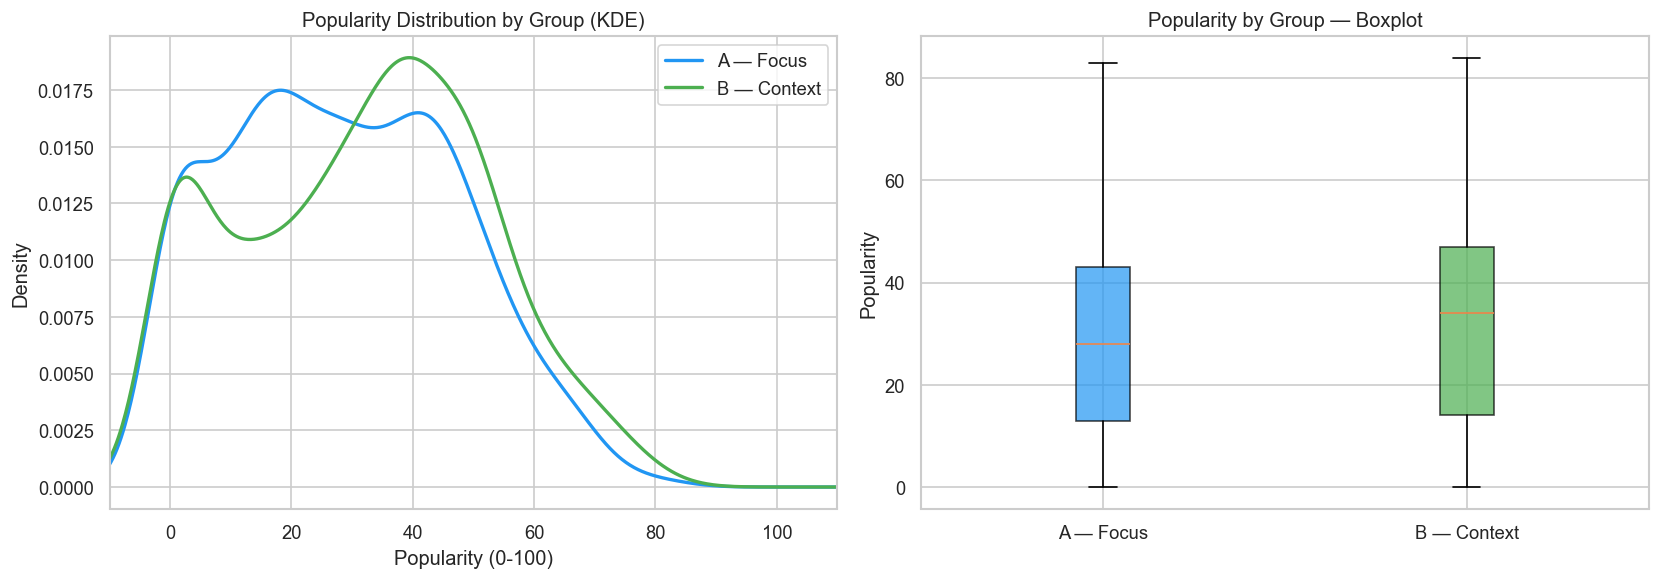

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in group_colors.items():
    subset = df_clean[df_clean['group'] == group]['popularity']
    subset.plot.kde(ax=axes[0], color=color, label=group_labels[group], linewidth=2)

axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Density')
axes[0].set_title('Popularity Distribution by Group (KDE)')
axes[0].legend()
axes[0].set_xlim(-10, 110)

bp_data = [df_clean[df_clean['group'] == g]['popularity'].values for g in ['A_focus', 'B_context']]
bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context']],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity by Group — Boxplot')

plt.tight_layout()
plt.savefig('../figures/full_01_popularity_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Popularity Distribution — Full Sample (n=2,016)

- Both groups show a similar bimodal shape: peak near 0-20 (niche tracks) and another near 35-45
- B — Context (green) has a higher peak in the 35-45 range — slightly more popular tracks
- A — Focus (blue) has more weight near 0-20 — more niche/unknown tracks
- Boxplots confirm: Context median (~33) > Focus median (~28)
- High variance in both groups — popularity is noisy regardless of music type

The difference is visible but small. Statistical testing in Notebook 2 will determine 
if it's significant.

/var/folders/t4/2qvfdw3d171bl74ql09bhmkh0000gn/T/ipykernel_46537/802947932.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context']],


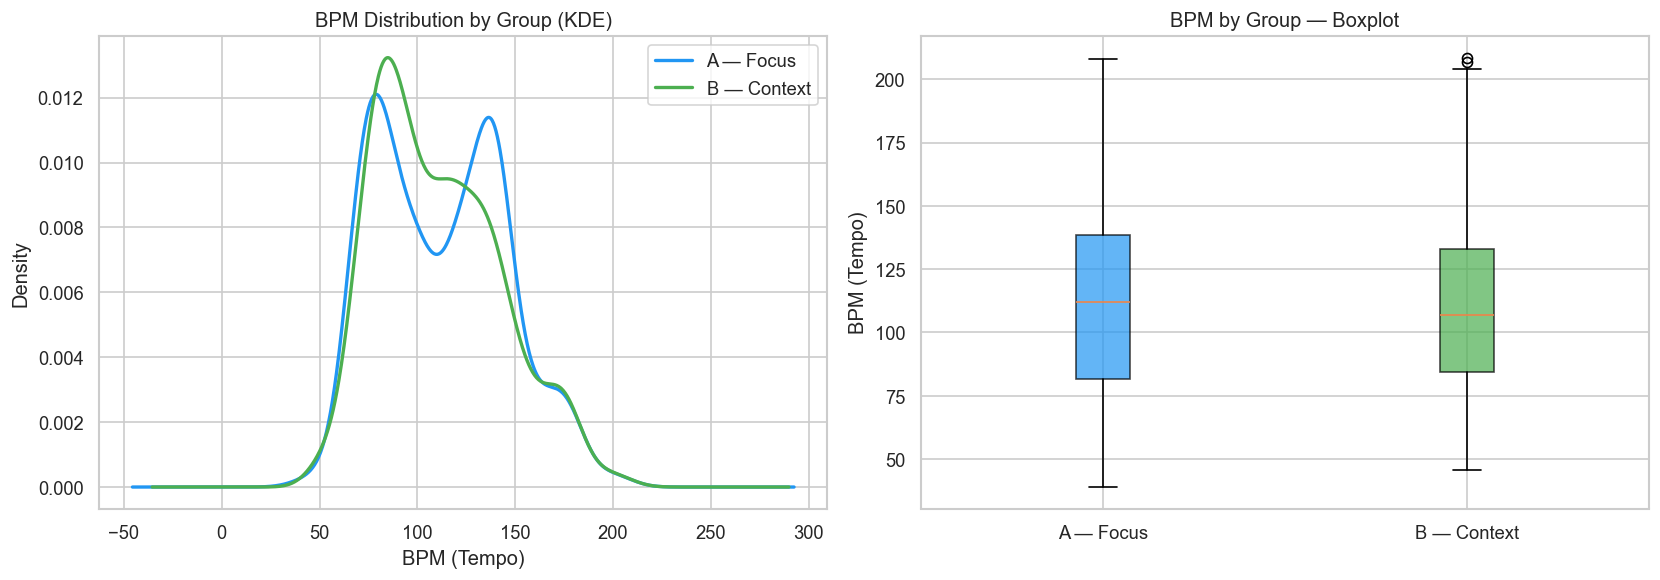

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group, color in group_colors.items():
    subset = df_clean[df_clean['group'] == group]['tempo']
    subset.plot.kde(ax=axes[0], color=color, label=group_labels[group], linewidth=2)

axes[0].set_xlabel('BPM (Tempo)')
axes[0].set_ylabel('Density')
axes[0].set_title('BPM Distribution by Group (KDE)')
axes[0].legend()

bp_data = [df_clean[df_clean['group'] == g]['tempo'].values for g in ['A_focus', 'B_context']]
bp = axes[1].boxplot(bp_data, labels=[group_labels[g] for g in ['A_focus', 'B_context']],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('BPM (Tempo)')
axes[1].set_title('BPM by Group — Boxplot')

plt.tight_layout()
plt.savefig('../figures/full_02_bpm_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## BPM Distribution — Full Sample (n=2,016)

- Both groups have nearly identical BPM distributions — peak around 75-80 and a second peak near 130
- Medians are almost the same: Focus ~110 BPM, Context ~105 BPM
- High variance in both groups (IQR ~75-135)
- **Focus music is not faster than context music** — the core assumption of the hypothesis does not hold in the data

This finding alone is striking: if focus music doesn't have higher BPM, 
then BPM cannot be the mechanism driving focus or engagement.

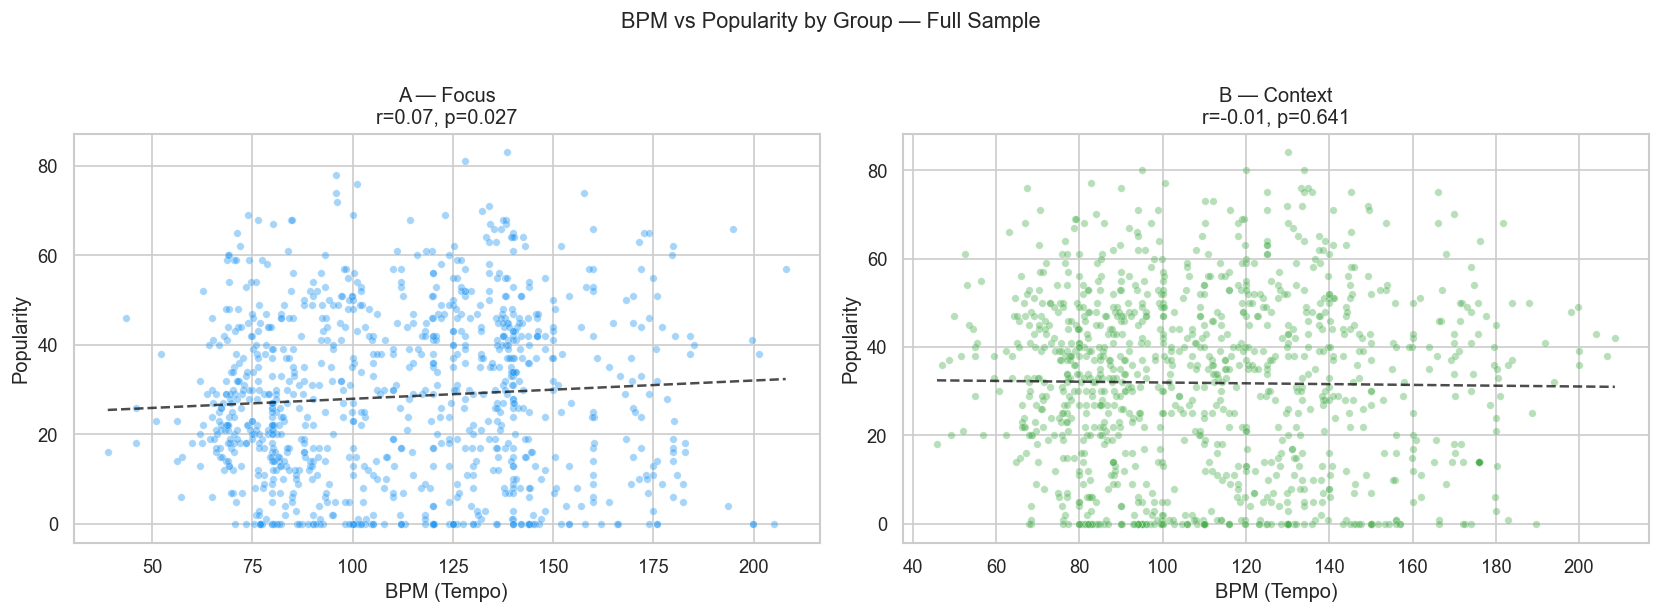

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (group, color) in zip(axes, group_colors.items()):
    subset = df_clean[df_clean['group'] == group]
    ax.scatter(subset['tempo'], subset['popularity'], alpha=0.4, color=color, 
               edgecolors='white', linewidth=0.3, s=20)
    
    # Trend line
    z = np.polyfit(subset['tempo'], subset['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['tempo'].min(), subset['tempo'].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    r, pval = stats.pearsonr(subset['tempo'], subset['popularity'])
    ax.set_title(f'{group_labels[group]}\nr={r:.2f}, p={pval:.3f}')
    ax.set_xlabel('BPM (Tempo)')
    ax.set_ylabel('Popularity')

plt.suptitle('BPM vs Popularity by Group — Full Sample', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/full_03_bpm_vs_popularity.png', dpi=120, bbox_inches='tight')
plt.show()

## BPM vs Popularity — Full Sample (n=2,016)

- **A — Focus:** r=0.07, p=0.027 — statistically significant but practically meaningless (r²=0.005, explains <1% of variance)
- **B — Context:** r=-0.01, p=0.641 — no correlation whatsoever

With n=947 we now have enough power to detect even tiny correlations — and the Focus 
group shows one (p=0.027). But r=0.07 is negligible in practice.

**Key takeaway:** BPM explains less than 1% of the variance in popularity, 
in either group. Tempo is not driving engagement.

This sets up the central finding of the project: something else is going on.
Notebook 4 (SHAP analysis) will reveal which features actually matter.